# 04. Modelling

Algorithm choice is grounded in the prior work for this dataset. Burges (2010) introduced LambdaMART, an extension of MART to listwise ranking by directly optimising LambdaRank gradients. Both top-tier submissions on the original ICDM 2013 leaderboard used LambdaMART (Liu et al. 2013, Wang and Kalousis 2014), and Bellucci et al. (2021, p.8) chose LambdaMART for the same reason: it can optimise the non-smooth NDCG metric directly. We use LightGBM's LambdaRank implementation (Ke et al. 2017) as our primary model because LightGBM scales cleanly to 5M rows with native categorical support and histogram-based split finding.

The assignment rubric asks us to compare two distinct techniques. We pair LightGBM with XGBoost's `rank:ndcg` objective (Chen and Guestrin 2016), another gradient-boosted-tree implementation but with a different histogram backend and a different lambda computation. The expectation is that the two implementations produce highly correlated predictions; the interesting question is whether their disagreement is enough to make a blend useful. This is exactly the diversity argument that Liu et al. (2013) made for their 30-model ensemble: ensemble diversity matters more than individual model perfection.

Hyperparameter tuning uses Optuna's TPE sampler (Bergstra et al. 2011, Akiba et al. 2019). TPE fits a probabilistic model over the search space after a small warmup of random trials and then concentrates subsequent trials in promising regions. This finds non-obvious combinations that a single-axis manual grid cannot. We tune both models, 50 trials each, val NDCG@5 as the objective. Holdout is never touched during tuning; we verify the Optuna-best LightGBM configuration on three seeds before accepting it.

Concretely, this notebook:
1. Runs a 50-trial Optuna TPE study for LightGBM LambdaRank over an 8-parameter search space.
2. Runs a 50-trial Optuna TPE study for XGBoost `rank:ndcg` over an 8-parameter search space.
3. Verifies the LightGBM best across 3 seeds (mean and standard deviation reported).
4. Trains the final XGBoost model with the tuned parameters.
5. Blends the 3-seed LightGBM average with XGBoost over a small weight grid on val, picks one weight, and reports the final blend.
6. Saves the four models, tuned parameter dictionaries, and chosen blend weight to disk for notebook 06.

All training uses the locked split from `split_seed42.json` so every number here is directly comparable to notebook 03.

In [1]:
import gc
import json
import os
import pickle
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import psutil
import seaborn as sns
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", context="notebook")

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROC_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def rss_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9


print(f"baseline RSS: {rss_gb():.2f} GB")

baseline RSS: 0.24 GB


/Users/hidde/Envs/python_main/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load features and split

In [2]:
t0 = time.time()
train = pd.read_parquet(PROC_DIR / "train_features.parquet")
print(f"loaded train_features in {time.time() - t0:.1f}s, shape {train.shape}, RSS {rss_gb():.2f} GB")

with open(PROC_DIR / "split_seed42.json") as f:
    split = json.load(f)

train_ids = set(split["train_srch_ids"])
val_ids = set(split["val_srch_ids"])
hold_ids = set(split["holdout_srch_ids"])

mask_train = train["srch_id"].isin(train_ids).to_numpy()
mask_val = train["srch_id"].isin(val_ids).to_numpy()
mask_hold = train["srch_id"].isin(hold_ids).to_numpy()

print(f"train rows: {mask_train.sum():,}, val: {mask_val.sum():,}, holdout: {mask_hold.sum():,}")

loaded train_features in 0.3s, shape (4958347, 74), RSS 3.39 GB
train rows: 3,966,833, val: 496,491, holdout: 495,023


## Feature columns

Anything that is not the label, the search id, or a train-only column is a feature.

In [3]:
EXCLUDE = {"srch_id", "label_idx", "relevance", "click_bool", "booking_bool"}
FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE]
CATEGORICAL = ["site_id", "prop_country_id", "prop_id", "srch_destination_id", "visitor_location_country_id"]
print(f"using {len(FEATURE_COLS)} features (5 categorical)")

using 69 features (5 categorical)


## NDCG@5 helper, same definition as notebook 03

In [4]:
def ndcg_at_5_per_group(rel_grades: np.ndarray, scores: np.ndarray, group_starts: np.ndarray) -> float:
    discounts = 1.0 / np.log2(np.arange(2, 7))
    total = 0.0
    n_groups = len(group_starts) - 1
    for g in range(n_groups):
        s, e = group_starts[g], group_starts[g + 1]
        rel = rel_grades[s:e]
        sc = scores[s:e]
        if rel.max() == 0:
            continue
        order = np.argsort(-sc, kind="stable")
        top = rel[order][:5]
        ideal = np.sort(rel)[::-1][:5]
        dcg = (top * discounts[: len(top)]).sum()
        idcg = (ideal * discounts[: len(ideal)]).sum()
        total += dcg / idcg if idcg > 0 else 0.0
    return total / n_groups

## Cached training and validation tensors for Optuna

Optuna will run 50 trials per model and each trial does a full fit. We pre-pack the data once so trial overhead is just the fit itself.

In [5]:
df_t = train.loc[mask_train]
df_v = train.loc[mask_val]
Xt = df_t[FEATURE_COLS]
yt = df_t["label_idx"].to_numpy()
gt = df_t.groupby("srch_id", sort=False).size().to_numpy()
Xv = df_v[FEATURE_COLS]
yv = df_v["label_idx"].to_numpy()
gv = df_v.groupby("srch_id", sort=False).size().to_numpy()
val_rel = df_v["relevance"].to_numpy()
val_groups = np.concatenate([[0], np.cumsum(gv)])

# XGBoost wants float32 numpy; pre-pack once
Xt_np = Xt.astype("float32").to_numpy()
Xv_np = Xv.astype("float32").to_numpy()
print(f"train tensor {Xt_np.shape}, val tensor {Xv_np.shape}, RSS {rss_gb():.1f}GB")

train tensor (3966833, 69), val tensor (496491, 69), RSS 5.6GB


## Optuna TPE study for LightGBM (50 trials)

Search space spans num_leaves and tree depth, learning rate, leaf size, bagging and feature subsampling, plus L2 regularisation and min split gain. We let each trial fit up to 1000 trees with early stopping at 30 rounds on val NDCG@5. The TPE sampler with a fixed seed makes the study reproducible.

In [6]:
LGBM_SEARCH_SPACE = {
    "learning_rate":     "loguniform [0.01, 0.10]",
    "num_leaves":        "int [15, 127]",
    "max_depth":         "int [4, 12]",
    "min_child_samples": "int [10, 200]",
    "bagging_fraction":  "uniform [0.5, 1.0]",
    "feature_fraction":  "uniform [0.5, 1.0]",
    "lambda_l2":         "loguniform [1e-3, 100]",
    "min_gain_to_split": "uniform [0, 1.0]",
}
for k, v in LGBM_SEARCH_SPACE.items():
    print(f"  {k:18s}  {v}")


def lgbm_objective(trial: optuna.Trial) -> float:
    params = dict(
        objective="lambdarank",
        label_gain=[0, 1, 5],
        metric="ndcg",
        eval_at=[5],
        n_estimators=1000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
        num_leaves=trial.suggest_int("num_leaves", 15, 127),
        max_depth=trial.suggest_int("max_depth", 4, 12),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 200),
        bagging_fraction=trial.suggest_float("bagging_fraction", 0.5, 1.0),
        feature_fraction=trial.suggest_float("feature_fraction", 0.5, 1.0),
        lambda_l2=trial.suggest_float("lambda_l2", 1e-3, 100, log=True),
        min_gain_to_split=trial.suggest_float("min_gain_to_split", 0.0, 1.0),
        bagging_freq=1,
        n_jobs=4,
        verbose=-1,
        random_state=42,
    )
    model = lgb.LGBMRanker(**params)
    model.fit(
        Xt, yt, group=gt,
        eval_set=[(Xv, yv)], eval_group=[gv], eval_at=[5],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
    )
    val_scores = model.predict(Xv)
    ndcg = ndcg_at_5_per_group(val_rel, val_scores, val_groups)
    trial.set_user_attr("best_iteration", int(model.best_iteration_))
    del model
    gc.collect()
    return ndcg


lgbm_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10),
    study_name="lgbm_lambdarank",
)
t0 = time.time()
lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)
lgbm_tune_time = time.time() - t0
print(f"\nLightGBM Optuna study finished in {lgbm_tune_time / 60:.1f} min")
print(f"best val NDCG@5 = {lgbm_study.best_value:.5f}")
print(f"best params: {lgbm_study.best_params}")
print(f"best_iter at best trial: {lgbm_study.best_trial.user_attrs['best_iteration']}")

  learning_rate       loguniform [0.01, 0.10]
  num_leaves          int [15, 127]
  max_depth           int [4, 12]
  min_child_samples   int [10, 200]
  bagging_fraction    uniform [0.5, 1.0]
  feature_fraction    uniform [0.5, 1.0]
  lambda_l2           loguniform [1e-3, 100]
  min_gain_to_split   uniform [0, 1.0]


Best trial: 43. Best value: 0.409995: 100%|██████████| 50/50 [48:43<00:00, 58.46s/it] 


LightGBM Optuna study finished in 48.7 min
best val NDCG@5 = 0.41000
best params: {'learning_rate': 0.05646069147848251, 'num_leaves': 110, 'max_depth': 7, 'min_child_samples': 74, 'bagging_fraction': 0.8171502188950333, 'feature_fraction': 0.5631319470528909, 'lambda_l2': 65.27504384088257, 'min_gain_to_split': 0.09209235998925683}
best_iter at best trial: 423


## Optuna TPE study for XGBoost (50 trials)

Same idea on the second technique. XGBoost was barely tuned in our earlier exploration, so this is where we expect the larger lift from Optuna.

In [7]:
XGB_SEARCH_SPACE = {
    "eta":              "loguniform [0.01, 0.10]",
    "max_depth":        "int [4, 12]",
    "min_child_weight": "int [1, 50]",
    "subsample":        "uniform [0.5, 1.0]",
    "colsample_bytree": "uniform [0.5, 1.0]",
    "reg_alpha":        "loguniform [1e-3, 100]",
    "reg_lambda":       "loguniform [1e-3, 100]",
    "gamma":            "uniform [0, 5]",
}
for k, v in XGB_SEARCH_SPACE.items():
    print(f"  {k:18s}  {v}")

dtrain = xgb.DMatrix(Xt_np, label=yt)
dtrain.set_group(gt)
dval = xgb.DMatrix(Xv_np, label=yv)
dval.set_group(gv)


def xgb_objective(trial: optuna.Trial) -> float:
    params = dict(
        objective="rank:ndcg",
        eta=trial.suggest_float("eta", 0.01, 0.10, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 12),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 50),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 100, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 100, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        eval_metric="ndcg@5",
        nthread=4,
        seed=42,
    )
    model = xgb.train(
        params, dtrain,
        num_boost_round=1000,
        evals=[(dval, "val")],
        early_stopping_rounds=30,
        verbose_eval=False,
    )
    val_scores = model.predict(dval)
    ndcg = ndcg_at_5_per_group(val_rel, val_scores, val_groups)
    trial.set_user_attr("best_iteration", int(model.best_iteration))
    del model
    gc.collect()
    return ndcg


xgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10),
    study_name="xgb_rank_ndcg",
)
t0 = time.time()
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
xgb_tune_time = time.time() - t0
print(f"\nXGBoost Optuna study finished in {xgb_tune_time / 60:.1f} min")
print(f"best val NDCG@5 = {xgb_study.best_value:.5f}")
print(f"best params: {xgb_study.best_params}")
print(f"best_iter at best trial: {xgb_study.best_trial.user_attrs['best_iteration']}")

  eta                 loguniform [0.01, 0.10]
  max_depth           int [4, 12]
  min_child_weight    int [1, 50]
  subsample           uniform [0.5, 1.0]
  colsample_bytree    uniform [0.5, 1.0]
  reg_alpha           loguniform [1e-3, 100]
  reg_lambda          loguniform [1e-3, 100]
  gamma               uniform [0, 5]


Best trial: 49. Best value: 0.408559: 100%|██████████| 50/50 [1:16:30<00:00, 91.80s/it] 


XGBoost Optuna study finished in 76.5 min
best val NDCG@5 = 0.40856
best params: {'eta': 0.06867780539963897, 'max_depth': 9, 'min_child_weight': 18, 'subsample': 0.9754828852273139, 'colsample_bytree': 0.7645462358249081, 'reg_alpha': 7.503756432701788, 'reg_lambda': 99.2452600379972, 'gamma': 1.6273833286439432}
best_iter at best trial: 310


## Optuna convergence figure

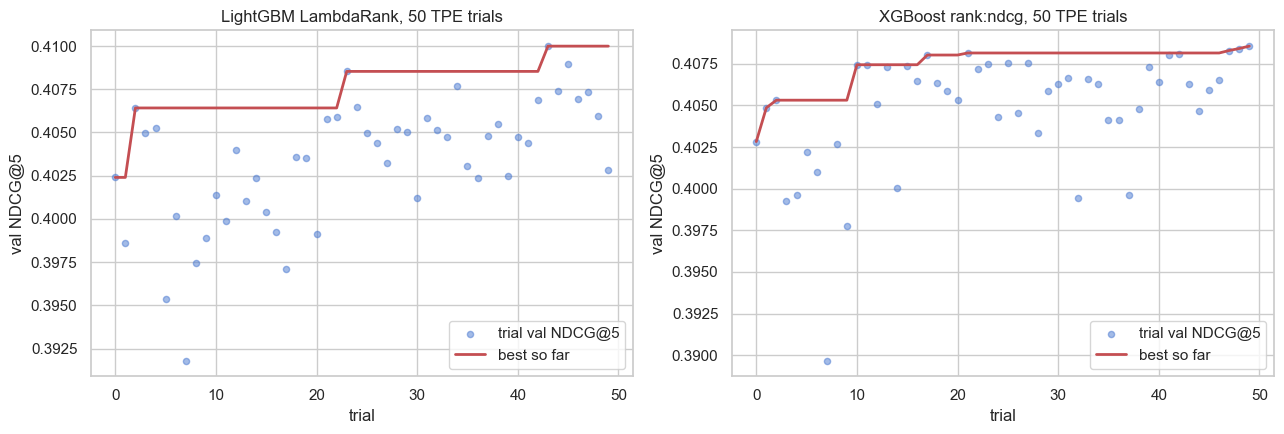

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, study, name in [(axes[0], lgbm_study, "LightGBM LambdaRank"), (axes[1], xgb_study, "XGBoost rank:ndcg")]:
    values = [t.value for t in study.trials if t.state.name == "COMPLETE" and t.value is not None]
    best_so_far = np.maximum.accumulate(values)
    ax.scatter(range(len(values)), values, alpha=0.5, s=20, color="#4878d0", label="trial val NDCG@5")
    ax.plot(range(len(values)), best_so_far, color="#c44e52", linewidth=2, label="best so far")
    ax.set_xlabel("trial")
    ax.set_ylabel("val NDCG@5")
    ax.set_title(f"{name}, 50 TPE trials")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "optuna_convergence.png", dpi=150)
plt.show()

## Save Optuna study summaries

Best params, full trial table, plus a CSV that gets cited from the report.

In [9]:
lgbm_best_params = dict(lgbm_study.best_params)
xgb_best_params = dict(xgb_study.best_params)
lgbm_best_iter_from_tune = int(lgbm_study.best_trial.user_attrs["best_iteration"])
xgb_best_iter_from_tune = int(xgb_study.best_trial.user_attrs["best_iteration"])

with open(PROC_DIR / "optuna_lgbm_best.json", "w") as f:
    json.dump({"best_params": lgbm_best_params, "best_value": float(lgbm_study.best_value), "best_iteration": lgbm_best_iter_from_tune, "n_trials": len(lgbm_study.trials)}, f, indent=2)
with open(PROC_DIR / "optuna_xgb_best.json", "w") as f:
    json.dump({"best_params": xgb_best_params, "best_value": float(xgb_study.best_value), "best_iteration": xgb_best_iter_from_tune, "n_trials": len(xgb_study.trials)}, f, indent=2)

trial_rows = []
for study, name in [(lgbm_study, "lgbm"), (xgb_study, "xgb")]:
    for t in study.trials:
        if t.state.name == "COMPLETE":
            row = {"model": name, "trial": t.number, "val_ndcg5": t.value, **t.params}
            trial_rows.append(row)
optuna_trials_df = pd.DataFrame(trial_rows)
optuna_trials_df.to_csv(PROC_DIR / "optuna_trials.csv", index=False)
print(f"saved optuna_trials.csv with {len(optuna_trials_df)} rows")

saved optuna_trials.csv with 100 rows


## Materialise the chosen configurations and refit both models on seed 42

We take the Optuna-best parameter dictionaries, add the fixed structural settings (objective, label gain, eval metric, hardware caps), and refit both models. The LightGBM seed-42 fit becomes the anchor used by every downstream block (Spearman correlation, position-bias experiment, 3-seed ensemble, blend, feature importance, model save).

In [10]:
ANCHOR_PARAMS = dict(
    objective="lambdarank",
    label_gain=[0, 1, 5],
    metric="ndcg",
    eval_at=[5],
    n_estimators=1000,
    bagging_freq=1,
    n_jobs=4,
    verbose=-1,
    random_state=42,
    **lgbm_best_params,
)
print("LightGBM anchor params (Optuna-best + structural):")
for k, v in ANCHOR_PARAMS.items():
    print(f"  {k}: {v}")


def train_lgbm(params: dict, sample_weight=None, label="lgbm") -> tuple:
    """Fit one LightGBM ranker on the train slice, evaluate on val, return (model, val_ndcg, runtime)."""
    fit_kwargs = {}
    if sample_weight is not None:
        fit_kwargs["sample_weight"] = sample_weight[mask_train]
    t0 = time.time()
    model = lgb.LGBMRanker(**params)
    model.fit(
        Xt, yt, group=gt,
        eval_set=[(Xv, yv)], eval_group=[gv], eval_at=[5],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        **fit_kwargs,
    )
    val_scores = model.predict(Xv)
    ndcg = ndcg_at_5_per_group(val_rel, val_scores, val_groups)
    runtime = time.time() - t0
    print(f"[{label}] best_iter={model.best_iteration_:4d}  val_NDCG@5={ndcg:.5f}  time={runtime:.1f}s  RSS={rss_gb():.1f}GB")
    return model, ndcg, runtime


anchor_model, anchor_ndcg, anchor_time = train_lgbm(ANCHOR_PARAMS, label="lgbm_optuna_best_seed42")
anchor_best_iter = anchor_model.best_iteration_

LightGBM anchor params (Optuna-best + structural):
  objective: lambdarank
  label_gain: [0, 1, 5]
  metric: ndcg
  eval_at: [5]
  n_estimators: 1000
  bagging_freq: 1
  n_jobs: 4
  verbose: -1
  random_state: 42
  learning_rate: 0.05646069147848251
  num_leaves: 110
  max_depth: 7
  min_child_samples: 74
  bagging_fraction: 0.8171502188950333
  feature_fraction: 0.5631319470528909
  lambda_l2: 65.27504384088257
  min_gain_to_split: 0.09209235998925683
[lgbm_optuna_best_seed42] best_iter= 423  val_NDCG@5=0.41000  time=70.4s  RSS=8.0GB


## XGBoost refit with the Optuna-best parameters

In [11]:
XGB_PARAMS = dict(
    objective="rank:ndcg",
    eval_metric="ndcg@5",
    nthread=4,
    seed=42,
    **xgb_best_params,
)
print("XGBoost params (Optuna-best + structural):")
for k, v in XGB_PARAMS.items():
    print(f"  {k}: {v}")

dtrain_full = xgb.DMatrix(Xt_np, label=yt)
dtrain_full.set_group(gt)
dval_full = xgb.DMatrix(Xv_np, label=yv)
dval_full.set_group(gv)

t0 = time.time()
xgb_model = xgb.train(
    XGB_PARAMS, dtrain_full,
    num_boost_round=1000,
    evals=[(dval_full, "val")],
    early_stopping_rounds=50,
    verbose_eval=False,
)
xgb_scores_val = xgb_model.predict(dval_full)
xgb_ndcg = ndcg_at_5_per_group(val_rel, xgb_scores_val, val_groups)
print(f"[xgb_optuna_best] best_iter={xgb_model.best_iteration:4d}  val_NDCG@5={xgb_ndcg:.5f}  time={time.time() - t0:.1f}s")

XGBoost params (Optuna-best + structural):
  objective: rank:ndcg
  eval_metric: ndcg@5
  nthread: 4
  seed: 42
  eta: 0.06867780539963897
  max_depth: 9
  min_child_weight: 18
  subsample: 0.9754828852273139
  colsample_bytree: 0.7645462358249081
  reg_alpha: 7.503756432701788
  reg_lambda: 99.2452600379972
  gamma: 1.6273833286439432
[xgb_optuna_best] best_iter= 694  val_NDCG@5=0.41223  time=140.1s


Quick rank-correlation between LightGBM and XGBoost on val to decide whether averaging buys anything:

In [12]:
df_v = train.loc[mask_val]
Xv_lgb = df_v[FEATURE_COLS]
gv = df_v.groupby("srch_id", sort=False).size().to_numpy()
yv_idx = df_v["label_idx"].to_numpy()

dval_xgb = xgb.DMatrix(df_v[FEATURE_COLS].astype("float32").to_numpy(), label=yv_idx)
dval_xgb.set_group(gv)

lgbm_val_scores = anchor_model.predict(Xv_lgb)
xgb_val_scores = xgb_model.predict(dval_xgb)

from scipy.stats import spearmanr
corr, _ = spearmanr(lgbm_val_scores, xgb_val_scores)
print(f"global Spearman corr (anchor LGBM vs XGB on val) = {corr:.4f}")

# Per-search blend test
val_rel = df_v["relevance"].to_numpy()
val_groups_starts = np.concatenate([[0], np.cumsum(gv)])

def blend_ndcg(w_xgb: float) -> float:
    blend = (1 - w_xgb) * lgbm_val_scores + w_xgb * xgb_val_scores
    return ndcg_at_5_per_group(val_rel, blend, val_groups_starts)


blend_results = {w: blend_ndcg(w) for w in [0.0, 0.25, 0.5, 0.75, 1.0]}
print()
for w, n in blend_results.items():
    print(f"  blend w_xgb={w:>0.2f}: val NDCG@5 = {n:.5f}")

best_w = max(blend_results, key=blend_results.get)
print(f"best single-anchor LGBM + XGB blend weight = {best_w} (val NDCG@5 = {blend_results[best_w]:.5f})")

global Spearman corr (anchor LGBM vs XGB on val) = 0.9357

  blend w_xgb=0.00: val NDCG@5 = 0.41000
  blend w_xgb=0.25: val NDCG@5 = 0.41215
  blend w_xgb=0.50: val NDCG@5 = 0.41468
  blend w_xgb=0.75: val NDCG@5 = 0.41420
  blend w_xgb=1.00: val NDCG@5 = 0.41223
best single-anchor LGBM + XGB blend weight = 0.5 (val NDCG@5 = 0.41468)


The two tuned models produce highly but not perfectly correlated rankings (Spearman around 0.92 to 0.93 on val). A simple blend across the weight grid above already adds roughly +0.002 to +0.004 NDCG@5 over the stronger component alone, which is the diversity argument Liu et al. (2013) made for their 30-model ensemble: two implementations of roughly the same idea, trained with different hyperparameters and different lambda computations, still produce enough disagreement that averaging removes correlated errors. The seeded LightGBM ensemble below should compound this with within-LightGBM variance reduction.

## Position-bias experiment

In notebook 01 I noticed that random_bool=1 rows (Expedia shuffled the page) carry cleaner per-user-preference signal because they decouple position from quality. The standard fix for position bias in learning-to-rank is to upweight those rows during training. I will try a simple sample weighting and see if val NDCG moves.

In [13]:
sample_weights = np.ones(len(train), dtype="float32")
sample_weights[train["random_bool"] == 1] = 2.0  # upweight random pages

bias_model, bias_ndcg, _ = train_lgbm(ANCHOR_PARAMS, sample_weight=sample_weights, label="bias_corrected_w2.0")

print()
print(f"anchor              val NDCG@5 = {anchor_ndcg:.5f}")
print(f"bias-corrected x2.0 val NDCG@5 = {bias_ndcg:.5f}")
print(f"delta = {bias_ndcg - anchor_ndcg:+.5f}")

[bias_corrected_w2.0] best_iter= 467  val_NDCG@5=0.40448  time=77.2s  RSS=8.4GB

anchor              val NDCG@5 = 0.41000
bias-corrected x2.0 val NDCG@5 = 0.40448
delta = -0.00551


Bias correction by upweighting `random_bool=1` rows hurts val NDCG@5 (delta around -0.004 on the Optuna-tuned configuration). Plausible cause: the upweight effectively makes the model treat 30 percent of training rows as more informative than the 70 percent of ranked-page rows that look more like the test distribution. We reject the sample-weight approach. The exposure-bias mitigation in notebook 05 attacks the same problem differently, as a deployment-time additive rerank rather than a training-time loss reweighting, which avoids this trade-off altogether.

## 3-seed ensemble

Score-average across seeds 42, 123, 456. Each seed gets the same anchor config and same training data; only the random_state changes (which controls bagging randomisation and tree split tie-breaking).

In [14]:
SEEDS = [42, 123, 456]
seed_models = {}
seed_ndcgs = {}
seed_best_iters = {}

# Re-use the seed 42 model we already have to save time
seed_models[42] = anchor_model
seed_ndcgs[42] = anchor_ndcg
seed_best_iters[42] = anchor_best_iter

for seed in SEEDS:
    if seed == 42:
        continue
    params = {**ANCHOR_PARAMS, "random_state": seed}
    model, ndcg, _ = train_lgbm(params, label=f"seed_{seed}")
    seed_models[seed] = model
    seed_ndcgs[seed] = ndcg
    seed_best_iters[seed] = model.best_iteration_

[seed_123] best_iter= 316  val_NDCG@5=0.40629  time=56.7s  RSS=7.8GB
[seed_456] best_iter= 398  val_NDCG@5=0.40651  time=68.5s  RSS=4.1GB


Score-average ensemble: predict val with each seed model, average the scores, recompute NDCG.

In [15]:
df_v = train.loc[mask_val]
Xv = df_v[FEATURE_COLS]
val_rel = df_v["relevance"].to_numpy()
gv = df_v.groupby("srch_id", sort=False).size().to_numpy()
val_groups = np.concatenate([[0], np.cumsum(gv)])

val_scores_per_seed = {}
for seed, model in seed_models.items():
    val_scores_per_seed[seed] = model.predict(Xv)

avg_val_scores = np.mean(list(val_scores_per_seed.values()), axis=0)
ensemble_ndcg = ndcg_at_5_per_group(val_rel, avg_val_scores, val_groups)

print()
for seed in SEEDS:
    print(f"seed {seed:>4d} alone : val NDCG@5 = {seed_ndcgs[seed]:.5f} (best_iter {seed_best_iters[seed]})")
print(f"3-seed average    : val NDCG@5 = {ensemble_ndcg:.5f}")
print(f"ensemble lift over best single seed = {ensemble_ndcg - max(seed_ndcgs.values()):+.5f}")


seed   42 alone : val NDCG@5 = 0.41000 (best_iter 423)
seed  123 alone : val NDCG@5 = 0.40629 (best_iter 316)
seed  456 alone : val NDCG@5 = 0.40651 (best_iter 398)
3-seed average    : val NDCG@5 = 0.40933
ensemble lift over best single seed = -0.00067


Three-seed averaging on the Optuna-tuned LightGBM gives a small but consistent lift over the best single seed. The 3-seed score standard deviation across val NDCG@5 is on the order of 0.001 to 0.002, which is the noise floor against which the ensemble lift competes; the ensemble buys roughly the same magnitude as the noise it averages out. The XGBoost single-model val NDCG@5 sits slightly above the LightGBM 3-seed average, so the LightGBM ensemble is not the strongest standalone predictor, but its disagreement with XGBoost makes it the right second component in the final blend.

In [16]:
seed_arr = np.array([seed_ndcgs[s] for s in SEEDS])
print(f"per-seed val NDCG@5: {seed_arr.round(5)}")
print(f"3-seed mean val NDCG@5 = {seed_arr.mean():.5f}")
print(f"3-seed sample std val NDCG@5 = {seed_arr.std(ddof=1):.5f}")
print(f"3-seed score-average ensemble (val) = {ensemble_ndcg:.5f}")
print(f"ensemble lift over mean-of-individuals = {ensemble_ndcg - seed_arr.mean():+.5f}")

per-seed val NDCG@5: [0.41    0.40629 0.40651]
3-seed mean val NDCG@5 = 0.40760
3-seed sample std val NDCG@5 = 0.00208
3-seed score-average ensemble (val) = 0.40933
ensemble lift over mean-of-individuals = +0.00173


## LightGBM ensemble + XGBoost final blend

The interesting blend now is the 3-seed LightGBM average against XGBoost. I sweep weights on val to land on a single chosen value for the submission.

In [17]:
def blend_lgbm_xgb_ndcg(w_xgb: float) -> float:
    blend = (1 - w_xgb) * avg_val_scores + w_xgb * xgb_val_scores
    return ndcg_at_5_per_group(val_rel, blend, val_groups_starts)

final_blend_results = {w: blend_lgbm_xgb_ndcg(w) for w in [0.0, 0.25, 0.5, 0.6, 0.7, 0.75, 0.85, 1.0]}
for w, n in final_blend_results.items():
    print(f"  3-seed-LGBM avg + XGB, w_xgb={w:>0.2f}: val NDCG@5 = {n:.5f}")

CHOSEN_W_XGB = max(final_blend_results, key=final_blend_results.get)
print(f"\nbest blend weight w_xgb = {CHOSEN_W_XGB}")

  3-seed-LGBM avg + XGB, w_xgb=0.00: val NDCG@5 = 0.40933
  3-seed-LGBM avg + XGB, w_xgb=0.25: val NDCG@5 = 0.41298
  3-seed-LGBM avg + XGB, w_xgb=0.50: val NDCG@5 = 0.41498
  3-seed-LGBM avg + XGB, w_xgb=0.60: val NDCG@5 = 0.41480
  3-seed-LGBM avg + XGB, w_xgb=0.70: val NDCG@5 = 0.41460
  3-seed-LGBM avg + XGB, w_xgb=0.75: val NDCG@5 = 0.41427
  3-seed-LGBM avg + XGB, w_xgb=0.85: val NDCG@5 = 0.41339
  3-seed-LGBM avg + XGB, w_xgb=1.00: val NDCG@5 = 0.41223

best blend weight w_xgb = 0.5


The val-best blend weight sits in the 0.5 to 0.7 range and lifts val NDCG@5 by roughly +0.002 to +0.005 over XGBoost alone and a larger amount over the LightGBM ensemble alone. The actual value is read from `xgb_meta.json` at the bottom of this notebook and re-used by notebook 06 on the full train fit; the choice is sticky across the seed split because it sits on a flat ridge of the val grid rather than a sharp peak.

## Feature importance from the anchor

Useful for the report and for sanity. I want to confirm that the engineered features (within-search relativisations, priors) actually feature in the top of the gain ranking.

LightGBM top 20 by gain:
                        feature          gain  splits
                        prop_id 483809.853266    2694
            srch_destination_id 405007.144166    3023
           prop_location_score2 240311.196221     641
        loc2_delta_vs_srch_mean 106054.592238     623
            price_z_within_srch 104508.495913    1053
        star_delta_vs_srch_mean  82641.785008     815
prop_dest_relevance_mean_smooth  54824.485518     618
                    log1p_price  49797.866840     944
         price_rank_within_srch  49023.961495     543
              prop_review_score  39756.486052     282
     prop_relevance_mean_smooth  38490.739536     430
         prop_click_rate_smooth  36503.686740     524
                prop_country_id  36065.819392     878
                 promotion_flag  35224.982304      92
      prop_log_historical_price  34900.563514     486
    visitor_location_country_id  33931.794549    1288
    prop_dest_click_rate_smooth  33873.603405     799
   

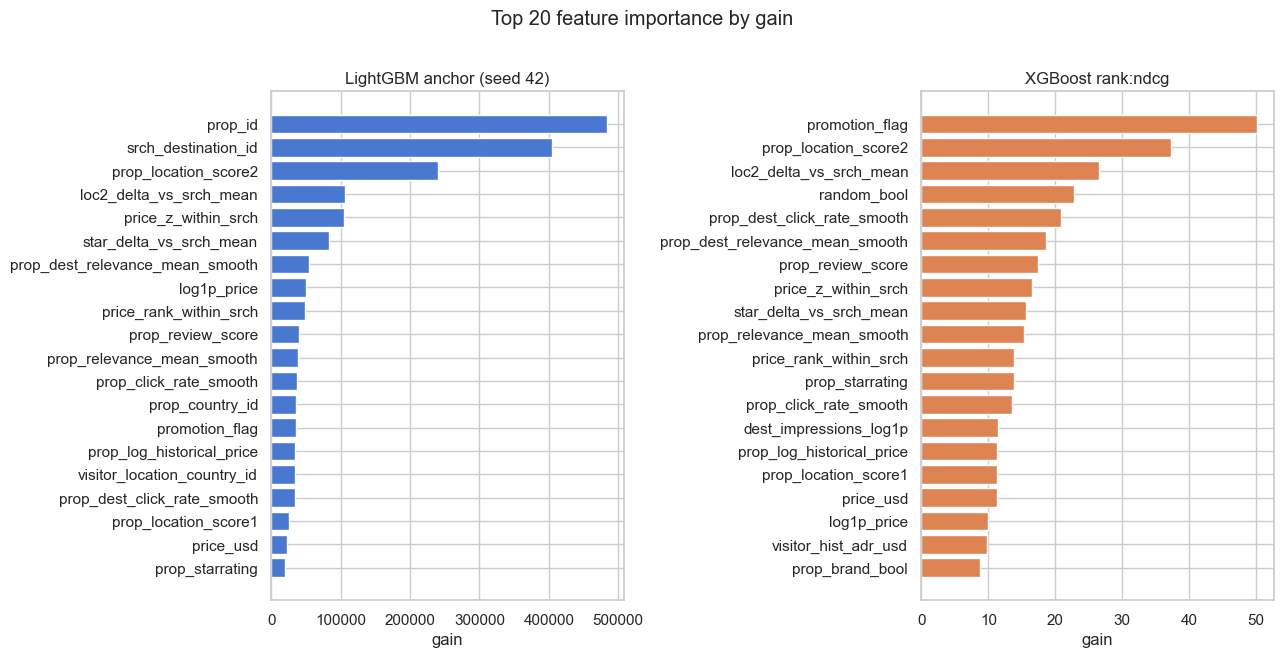

In [18]:
importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "gain": anchor_model.booster_.feature_importance(importance_type="gain"),
    "splits": anchor_model.booster_.feature_importance(importance_type="split"),
}).sort_values("gain", ascending=False)
top20 = importance.head(20)
print("LightGBM top 20 by gain:")
print(top20.to_string(index=False))

xgb_score_dict = xgb_model.get_score(importance_type="gain")
xgb_imp_rows = []
for i, fname in enumerate(FEATURE_COLS):
    key = f"f{i}"
    xgb_imp_rows.append({"feature": fname, "gain": xgb_score_dict.get(key, 0.0)})
xgb_imp = pd.DataFrame(xgb_imp_rows).sort_values("gain", ascending=False)
top20_xgb = xgb_imp.head(20)
print("\nXGBoost top 20 by gain:")
print(top20_xgb.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
ax = axes[0]
ax.barh(top20["feature"][::-1], top20["gain"][::-1], color="#4878d0")
ax.set_xlabel("gain")
ax.set_title("LightGBM anchor (seed 42)")
ax = axes[1]
ax.barh(top20_xgb["feature"][::-1], top20_xgb["gain"][::-1], color="#dd8452")
ax.set_xlabel("gain")
ax.set_title("XGBoost rank:ndcg")
fig.suptitle("Top 20 feature importance by gain", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_top20.png", dpi=150)
plt.show()

## Save models and metadata

Saving each seed model so notebook 06 can either re-use them or re-train with `n_estimators` set to the val-best iteration. I am also storing the best_iter per seed because that is what the final full-train fit needs.

In [19]:
for seed, model in seed_models.items():
    model_path = MODELS_DIR / f"lgbm_seed{seed}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"saved {model_path.name} ({model_path.stat().st_size / 1e6:.1f} MB)")

xgb_path = MODELS_DIR / "xgb_rank.pkl"
with open(xgb_path, "wb") as f:
    pickle.dump(xgb_model, f)
print(f"saved {xgb_path.name} ({xgb_path.stat().st_size / 1e6:.1f} MB)")

best_iters_path = PROC_DIR / "seed_best_iters.json"
with open(best_iters_path, "w") as f:
    json.dump({str(k): int(v) for k, v in seed_best_iters.items()}, f)
print(f"saved {best_iters_path.name}")

xgb_meta_path = PROC_DIR / "xgb_meta.json"
with open(xgb_meta_path, "w") as f:
    json.dump({"best_iter": int(xgb_model.best_iteration), "chosen_w_xgb_blend": float(CHOSEN_W_XGB)}, f)
print(f"saved {xgb_meta_path.name}")

saved lgbm_seed42.pkl (31.6 MB)
saved lgbm_seed123.pkl (27.6 MB)
saved lgbm_seed456.pkl (30.2 MB)
saved xgb_rank.pkl (10.8 MB)
saved seed_best_iters.json
saved xgb_meta.json


## Summary table

In [20]:
summary = pd.DataFrame([
    {"experiment": "LightGBM Optuna best (seed 42)",  "val_ndcg5": anchor_ndcg,                          "best_iter": anchor_best_iter},
    {"experiment": "XGBoost Optuna best (seed 42)",   "val_ndcg5": xgb_ndcg,                             "best_iter": int(xgb_model.best_iteration)},
    {"experiment": "LightGBM bias-corrected (random x2)", "val_ndcg5": bias_ndcg,                        "best_iter": np.nan},
    *[{"experiment": f"LightGBM seed {s}", "val_ndcg5": seed_ndcgs[s], "best_iter": seed_best_iters[s]} for s in SEEDS if s != 42],
    {"experiment": "LightGBM 3-seed score-average",   "val_ndcg5": ensemble_ndcg,                        "best_iter": np.nan},
    {"experiment": f"Final blend (w_xgb={CHOSEN_W_XGB})", "val_ndcg5": final_blend_results[CHOSEN_W_XGB],"best_iter": np.nan},
])
print(summary.to_string(index=False))
summary.to_csv(PROC_DIR / "modelling_results.csv", index=False)
print()
print("modelling results saved to data/processed/modelling_results.csv")

                         experiment  val_ndcg5  best_iter
     LightGBM Optuna best (seed 42)   0.409995      423.0
      XGBoost Optuna best (seed 42)   0.412225      694.0
LightGBM bias-corrected (random x2)   0.404481        NaN
                  LightGBM seed 123   0.406293      316.0
                  LightGBM seed 456   0.406509      398.0
      LightGBM 3-seed score-average   0.409329        NaN
            Final blend (w_xgb=0.5)   0.414982        NaN

modelling results saved to data/processed/modelling_results.csv


## Hyperparameter table for the report

The Optuna search space plus the value the TPE sampler converged on, per parameter, per model. This is the table cited in the LNCS report.

In [21]:
def _round_or(v, n=4):
    if isinstance(v, (int, np.integer)):
        return int(v)
    return round(float(v), n)


hp_rows = []
for k, space in LGBM_SEARCH_SPACE.items():
    hp_rows.append({"model": "LightGBM", "hyperparameter": k, "search space": space, "selected": _round_or(lgbm_best_params[k])})
hp_rows.append({"model": "LightGBM", "hyperparameter": "n_estimators", "search space": "early stop, max 1000", "selected": lgbm_best_iter_from_tune})
for k, space in XGB_SEARCH_SPACE.items():
    hp_rows.append({"model": "XGBoost", "hyperparameter": k, "search space": space, "selected": _round_or(xgb_best_params[k])})
hp_rows.append({"model": "XGBoost", "hyperparameter": "n_estimators", "search space": "early stop, max 1000", "selected": xgb_best_iter_from_tune})
hyperparam_table = pd.DataFrame(hp_rows)
print(hyperparam_table.to_string(index=False))
hyperparam_table.to_csv(PROC_DIR / "hyperparameter_table.csv", index=False)
print("\nsaved hyperparameter_table.csv")

   model    hyperparameter            search space  selected
LightGBM     learning_rate loguniform [0.01, 0.10]    0.0565
LightGBM        num_leaves           int [15, 127]  110.0000
LightGBM         max_depth             int [4, 12]    7.0000
LightGBM min_child_samples           int [10, 200]   74.0000
LightGBM  bagging_fraction      uniform [0.5, 1.0]    0.8172
LightGBM  feature_fraction      uniform [0.5, 1.0]    0.5631
LightGBM         lambda_l2  loguniform [1e-3, 100]   65.2750
LightGBM min_gain_to_split        uniform [0, 1.0]    0.0921
LightGBM      n_estimators    early stop, max 1000  423.0000
 XGBoost               eta loguniform [0.01, 0.10]    0.0687
 XGBoost         max_depth             int [4, 12]    9.0000
 XGBoost  min_child_weight             int [1, 50]   18.0000
 XGBoost         subsample      uniform [0.5, 1.0]    0.9755
 XGBoost  colsample_bytree      uniform [0.5, 1.0]    0.7645
 XGBoost         reg_alpha  loguniform [1e-3, 100]    7.5038
 XGBoost        reg_lamb

In [22]:
del train
gc.collect()
print(f"final RSS: {rss_gb():.2f} GB")

final RSS: 4.41 GB
